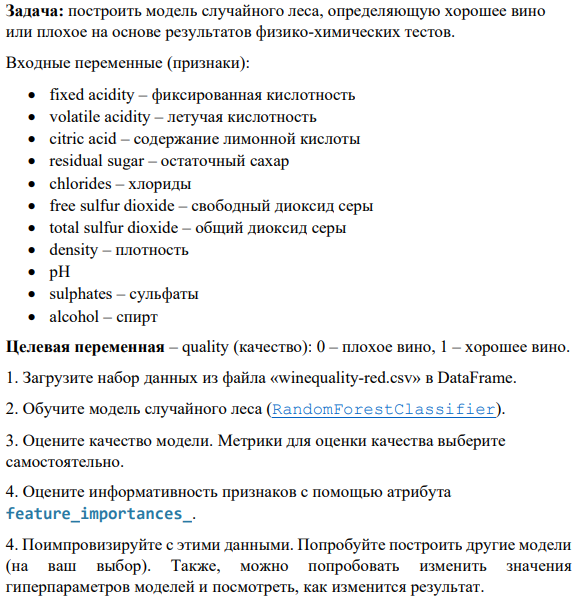

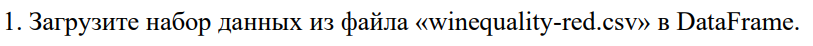

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('winequality-red.csv', sep=',', decimal=',')

# Бинарная целевая переменная: quality >= 7 → 1 (хорошее), иначе 0 (плохое)

feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

X = df[feature_cols]
y = df['quality']

print(y.value_counts().to_string())

quality
1    855
0    744


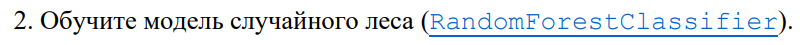
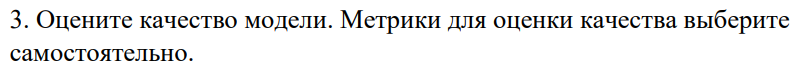

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(f"Train accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {rf.score(X_test, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,labels=[0,1], target_names=['плохое', 'хорошее']))

Train accuracy: 1.0000
Test accuracy:  0.7766

Classification Report:
              precision    recall  f1-score   support

      плохое       0.75      0.77      0.76       298
     хорошее       0.80      0.78      0.79       342

    accuracy                           0.78       640
   macro avg       0.78      0.78      0.78       640
weighted avg       0.78      0.78      0.78       640



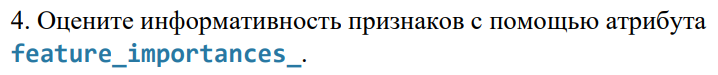

In [39]:
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feat_imp.to_string(index=False))

             feature  importance
             alcohol    0.190196
           sulphates    0.136169
total sulfur dioxide    0.107248
    volatile acidity    0.106922
             density    0.085049
           chlorides    0.074857
       fixed acidity    0.064977
                  pH    0.061889
 free sulfur dioxide    0.059854
         citric acid    0.058731
      residual sugar    0.054108


In [40]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)

print("Поиск оптимальных параметров...")
grid.fit(X_train, y_train)
print("Готово!")

print(f"\nЛучшие параметры: {grid.best_params_}")
print(f"CV score: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f"\nОптимальная модель:")
print(f"Train accuracy: {best_rf.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {best_rf.score(X_test, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, labels=[0, 1], target_names=['плохое', 'хорошее']))

Поиск оптимальных параметров...
Готово!

Лучшие параметры: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
CV score: 0.8123

Оптимальная модель:
Train accuracy: 0.9896
Test accuracy:  0.7781

Classification Report:
              precision    recall  f1-score   support

      плохое       0.76      0.77      0.76       298
     хорошее       0.80      0.79      0.79       342

    accuracy                           0.78       640
   macro avg       0.78      0.78      0.78       640
weighted avg       0.78      0.78      0.78       640



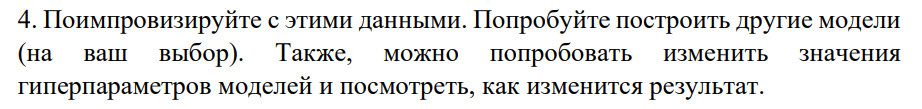

In [41]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("DecisionTree (max_depth=5):")
print(f"Train accuracy: {dt.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {dt.score(X_test, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, labels=[0, 1], target_names=['плохое', 'хорошее']))

DecisionTree (max_depth=5):
Train accuracy: 0.8102
Test accuracy:  0.7203

Classification Report:
              precision    recall  f1-score   support

      плохое       0.75      0.59      0.66       298
     хорошее       0.70      0.83      0.76       342

    accuracy                           0.72       640
   macro avg       0.73      0.71      0.71       640
weighted avg       0.73      0.72      0.72       640



In [42]:
comparison = pd.DataFrame({
    'Model': ['RandomForest (базовый)', 'RandomForest (оптимальный)', 'DecisionTree (max_depth=5)'],
    'Train Accuracy': [
        rf.score(X_train, y_train),
        best_rf.score(X_train, y_train),
        dt.score(X_train, y_train)
    ],
    'Test Accuracy': [
        rf.score(X_test, y_test),
        best_rf.score(X_test, y_test),
        dt.score(X_test, y_test)
    ]
})

print(comparison.to_string(index=False))

                     Model  Train Accuracy  Test Accuracy
    RandomForest (базовый)        1.000000       0.776563
RandomForest (оптимальный)        0.989572       0.778125
DecisionTree (max_depth=5)        0.810219       0.720313
